In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.optimize import minimize, Bounds
from GASModels.simulation.simulator import Simulator
from GASModels.dynamics import Dynamics
from GASModels.distributions.gamma_log_link import GammaLogLinkDistribution
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution

## Thesis

In [2]:
xls = pd.read_csv('data/precipitation.csv')

In [3]:
monthly_zeros

NameError: name 'monthly_zeros' is not defined

In [4]:
mz = monthly_zeros.groupby('month').mean().reset_index()

NameError: name 'monthly_zeros' is not defined

In [5]:
mz

NameError: name 'mz' is not defined

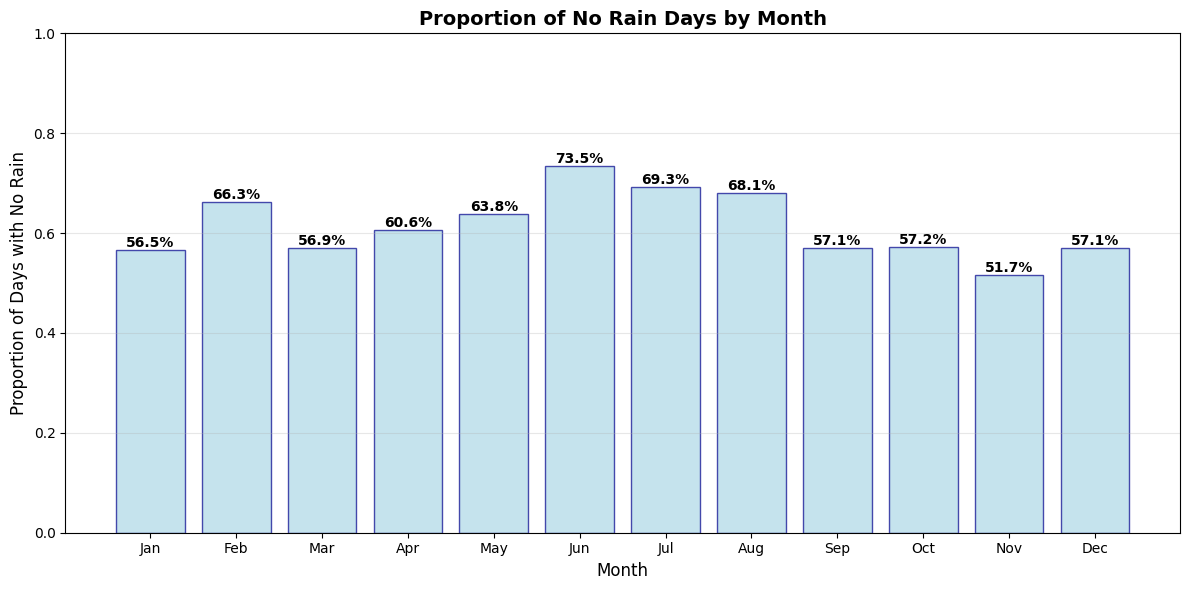

In [33]:
xls = pd.read_csv('data/precipitation.csv')


# Create the bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(mz['month'], mz['zeros'], 
               color='lightblue', edgecolor='darkblue', alpha=0.7)

# Customize the plot
plt.xlabel('Month', fontsize=12)
plt.ylabel('Proportion of Days with No Rain', fontsize=12)
plt.title('Proportion of No Rain Days by Month', fontsize=14, fontweight='bold')

# Set month names as x-axis labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)

# Add value labels on top of bars (as percentages)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Assuming your series is in a column called 'values' - adjust accordingly
# Count zeros for each day (1 if value is 0, 0 otherwise)
monthly_counts = pd.DataFrame({
    'zeros': (xls['precipitation'] == 0).astype(int),
    'year': xls.index.year,
    'month': xls.index.month
})

# Group by year and month, then sum the zeros (count them)
monthly_zero_counts = monthly_counts.groupby(['year', 'month'])['zeros'].sum().reset_index()

# Now calculate the mean count of zeros for each month across all years
monthly_avg_zeros = monthly_zero_counts.groupby('month')['zeros'].mean()

In [24]:
monthly_avg_zeros

month
1    3769.0
Name: zeros, dtype: float64

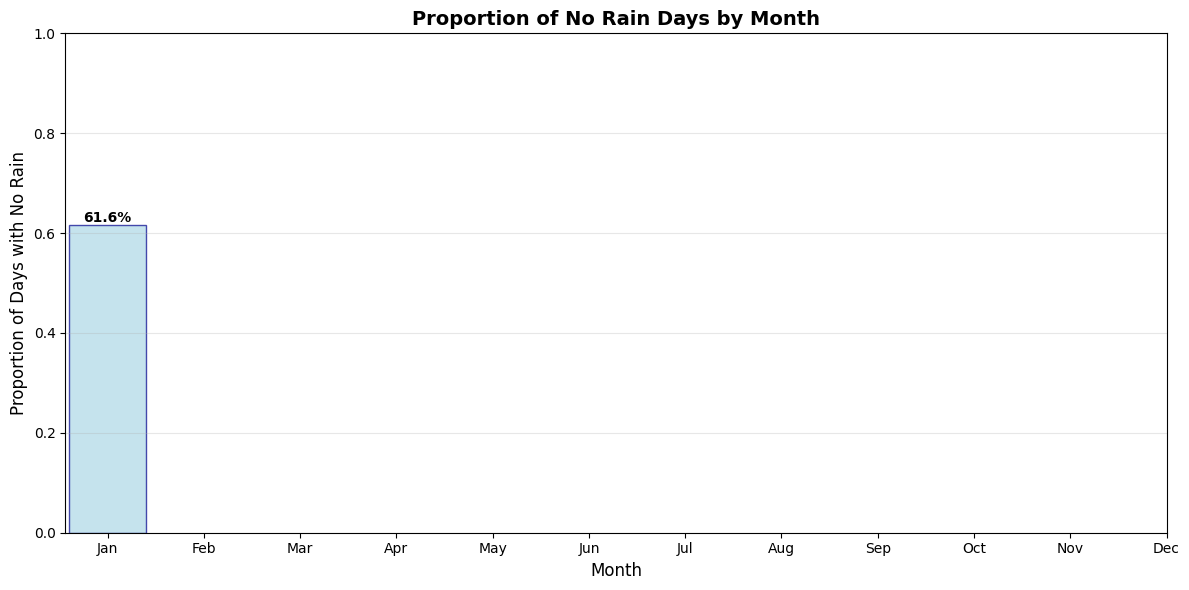

In [27]:
xls = pd.read_csv('data/precipitation.csv')
xls.index = pd.to_datetime(xls.index)

# Create DataFrame with zeros (1 for no rain, 0 for rain)
monthly_counts = pd.DataFrame({
    'zeros': (xls['precipitation'] == 0).astype(int),
    'year': xls.index.year,
    'month': xls.index.month
})

# Group by month and calculate mean
monthly_avg = monthly_counts.groupby('month')['zeros'].mean()

# Create the bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_avg.index, monthly_avg.values, 
               color='lightblue', edgecolor='darkblue', alpha=0.7)

# Customize the plot
plt.xlabel('Month', fontsize=12)
plt.ylabel('Proportion of Days with No Rain', fontsize=12)
plt.title('Proportion of No Rain Days by Month', fontsize=14, fontweight='bold')

# Set month names as x-axis labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)

# Add value labels on top of bars (as percentages)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
xls['precipitation'][-1825:]

4297     0.0
4298     0.0
4299     0.0
4300     0.0
4301     0.0
        ... 
6117    10.2
6118     9.6
6119     0.0
6120     0.0
6121     0.0
Name: precipitation, Length: 1825, dtype: float64

In [ ]:
# Create dynamics object
dynamics = Dynamics(
    distribution=ZAGB2LogLinkDistribution(),
    n=len(xls['precipitation'][-730:]),
    trend=None,
    seasonality=None,
    harmonics=20,
    period=365.25,
    time_varying_indices=[0],
    fixed_params_indices=[1],
    args=[0.05, 0.02]
)


In [ ]:
def objective_function(params, y, distribution):
    """
    Proper objective function: negative log-likelihood
    """
    # Unpack parameters - ZAGB2 needs 6 parameters
    delta_0, delta_1, gamma, xi, zeta = params
    delta_0 = delta_0 / 100
    delta_1 = delta_1 / 100
    gamma = gamma / 100
    xi = xi / 100
    zeta = zeta / 100
    phi = np.ones(len(y))
    
    total_loglik = 0.0
    
    for t in range(len(y)):
        try:
            if phi[t] <= 0 or gamma <= 0 or xi <= 0 or zeta <= 0:
                return np.inf
            if np.exp(zeta) <= np.exp(gamma):
                return np.inf
            loglik = distribution.logpdf(
                y[t],
                delta_0=delta_0,
                delta_1=delta_1, 
                phi=phi[t],
                gamma=gamma,
                xi=xi,
                zeta=zeta
            )
            total_loglik += loglik
        except:
            # Return large value if numerical issues
            return 1e10
    
    # Return negative log-likelihood for minimization
    return -total_loglik

# Initial guess for all 6 parameters
initial_guess = [100, 100, 100, 100, 200]  # delta_0, delta_1, gamma, xi, zeta

result = minimize(
    objective_function,
    x0=initial_guess,
    args=(xls['precipitation'][-730:], ZAGB2LogLinkDistribution()),
    method='BFGS',
    options={
        'gtol': 1e-6,
        'maxiter': 1000,
        'disp': True
    }
)

Optimization terminated successfully.
         Current function value: 10000000000.000000
         Iterations: 0
         Function evaluations: 6
         Gradient evaluations: 1


In [7]:
result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 10000000000.0
        x: [ 1.000e+02  1.000e+02  1.000e+02  1.000e+02  2.000e+02]
      nit: 0
      jac: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 6
     njev: 1

In [9]:
(xls['precipitation'][0:3650] > 0).sum() / 3650

np.float64(0.4115068493150685)

In [5]:
initial_params = dynamics.get_initial_values(xls['precipitation'][-730:])

Initial parameter check:
km: 20 (bounds: 1-2000) - OK
kg: 50 (bounds: 1-2000) - OK
gamma_0: 0.0 (bounds: -200-200) - OK
mu0: 10 (bounds: -1000-1000) - OK
delta_0: 50 (bounds: -200-200) - OK
delta_1: 50 (bounds: -100-100) - OK
gamma_: 100 (bounds: 10-500) - OK
xi: 200 (bounds: 10-500) - OK
zeta: 215 (bounds: 20-1000) - OK
zeta > gamma_: True - OK


In [6]:
initial_params

array([ 20.,  50.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  10.,  50.,
        50., 100., 200., 215.])

In [7]:
bounds = [
    # km, kg - learning rates (will be divided by 1000)
    (-2000, 2000),      # km: results in 0.001 to 2.0 after scaling
    (-2000, 2000),      # kg: results in 0.001 to 2.0 after scaling
] + [
    # 40 seasonal parameters (20 gamma + 20 gamma_star)
    (-200, 200) for _ in range(40)
] + [
    # 6 distribution parameters
    (-1000, 1000),  # mu0: results in -10.0 to 10.0 after scaling
    (-2000, 2000),    # delta_0: results in -2.0 to 2.0 after scaling  
    (-1000, 1000),    # delta_1: results in -1.0 to 1.0 after scaling
    (0, 10000),      # gamma_: results in 0.1 to 5.0 after scaling (must be > 0)
    (0, 10000),      # xi: results in 0.1 to 5.0 after scaling (must be > 0)
    (0, 10000)      # zeta: results in 0.2 to 10.0 after scaling (must be > gamma_)
]

# Test the objective function first
print("Testing objective function with initial parameters...")
test_value = dynamics.objective(initial_params, xls['precipitation'][0:730], bounds)
print(f"Initial objective value: {test_value}")

if np.isinf(test_value):
    print("CRITICAL: Objective returns inf even with initial parameters")
    print("Debugging step by step...")
    
    # Test with even simpler parameters
    simple_params = np.array([
        20, 20,                           # km, kg
        *[0] * 80,                         # seasonal  
        0, 10, 5, 33, 68, 66          # distribution
    ])
    
    simple_test = dynamics.objective(simple_params, xls['precipitation'][0:10], bounds)  # Small sample
    print(f"Simple test: {simple_test}")
else:
    # Only run optimization if initial test passes
    result = minimize(
        dynamics.objective,
        x0=initial_params,
        args=(xls['precipitation'][-730:], bounds),
        method='BFGS',
        options={
            'gtol': 1e-3,
            'maxiter': 100,
            'disp': True
        }
    )

Testing objective function with initial parameters...
Initial objective value: 2.5778780232199296


c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


         Current function value: 1.908760
         Iterations: 4
         Function evaluations: 792
         Gradient evaluations: 16


c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [8]:
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 1.9087601181555292
        x: [ 2.004e+01  3.843e+01 ...  2.101e+02  1.921e+02]
      nit: 4
      jac: [ 1.901e-05  1.527e-03 ... -3.130e-03  4.152e-03]
 hess_inv: [[ 1.006e+00 -1.760e+00 ...  1.540e+00 -3.488e+00]
            [-1.760e+00  5.057e+02 ... -4.417e+02  1.000e+03]
            ...
            [ 1.540e+00 -4.417e+02 ...  3.876e+02 -8.756e+02]
            [-3.488e+00  1.000e+03 ... -8.756e+02  1.984e+03]]
     nfev: 792
     njev: 16

In [8]:
dynamics.objective(result['x'], xls['precipitation'][0:730], bounds)

np.float64(2.3963140361132504)

In [9]:
result['x']

array([ 1.90525653e+01,  3.25097530e+01, -4.77372364e-03,  1.07104851e-01,
        4.16809626e-02,  2.92679371e-02,  7.78341546e-02,  7.46296165e-03,
        8.19258377e-02, -1.05514626e-01,  5.70824203e-02, -1.25771633e-02,
       -2.74524336e-02,  9.03782596e-03, -1.33053805e-02,  2.59320852e-02,
        7.59298593e-02, -5.71022801e-02,  1.15675047e-02,  6.73553868e-02,
       -6.90227849e-03,  1.42829294e-01, -4.59517474e-02, -1.01046991e-02,
        2.41195038e-02, -8.17487996e-02,  4.84259172e-02, -2.07407309e-02,
       -3.91445859e-03,  1.20303610e-02, -6.24247388e-02,  7.30390118e-02,
        3.36950816e-02, -5.14210198e-02,  8.42413737e-02,  3.49151435e-02,
        4.00869817e-02,  1.30715188e-01, -6.71808529e-02,  9.41424277e-02,
       -2.83845012e-02,  6.47288723e-02,  1.04701455e+01,  3.48960580e+01,
        4.12652761e+01,  1.32609024e+02,  2.15781486e+02,  1.66125666e+02])

In [39]:
result['jac']

array([ 1.90138817e-05,  1.52668357e-03, -1.59591436e-05, -1.76280737e-05,
        4.81307507e-05,  2.11149454e-05, -1.02370977e-05,  3.80128622e-05,
        3.50326300e-05, -1.01923943e-05, -2.55852938e-05, -2.20090151e-05,
       -1.88350677e-05,  6.06924295e-05,  4.01586294e-05,  9.96440649e-05,
        3.83555889e-05, -8.88109207e-06,  2.88039446e-05, -3.75360250e-05,
        5.75929880e-05, -7.09444284e-05, -4.00096178e-05,  3.41236591e-05,
        2.68220901e-07, -2.92360783e-05,  2.88933516e-05, -5.70714474e-05,
        6.16014004e-05, -4.93824482e-05,  1.03265047e-05,  7.10040331e-05,
       -2.52723694e-05,  4.61190939e-05, -6.49690628e-05, -2.37673521e-05,
        4.21851873e-05,  3.33786011e-06, -7.31647015e-06,  7.61747360e-05,
       -4.65661287e-05, -1.04054809e-04, -4.25875187e-05,  2.19307840e-03,
       -2.67192721e-04, -2.31327116e-03, -3.13006341e-03,  4.15198505e-03])

In [10]:
fis = result['x']

In [11]:
fis

array([ 2.00403070e+01,  3.84280871e+01, -4.81851809e-02,  1.75973072e-01,
       -6.72164340e-02, -7.70918085e-02,  1.18680996e-01, -1.12217145e-01,
        2.93773073e-02, -5.18625458e-03,  2.57787416e-02,  8.45992368e-02,
        1.10301148e-01, -2.41390811e-01, -5.01196512e-02, -2.31111949e-01,
        2.15694487e-03, -4.71065830e-02,  3.08349150e-02,  2.41123376e-01,
       -5.64046856e-02,  2.65566288e-02, -1.19948855e-04, -9.46388601e-02,
        7.40019847e-02,  2.56134814e-02, -2.33833379e-02,  2.17697311e-01,
       -1.46379102e-01,  6.94003301e-03,  4.77409974e-02, -2.05726584e-01,
        1.35746224e-01, -2.51844390e-01,  1.09228119e-01,  1.97743519e-03,
       -4.62877618e-02, -5.31054101e-02,  2.38571827e-01, -2.39382860e-01,
       -3.40887251e-02,  1.64843296e-01,  1.08392412e+01,  4.14421293e+01,
        4.27591507e+01,  1.20897070e+02,  2.10123328e+02,  1.92063105e+02])

In [19]:
len(xls['precipitation'].values[0:730])

730

In [21]:
phi = mu0 + np.sum(gamma)

In [22]:
phi

np.float64(0.10977528656585399)

In [24]:
from scipy.special import digamma, polygamma, beta

In [47]:
np.exp(zeta)

np.float64(1.833903572116884)

In [12]:
beta(np.exp(2) + np.exp(1), np.exp(2) - np.exp(1))

np.float64(0.00014182796938023182)

In [40]:
beta(np.exp(xi), np.exp(zeta))

np.float64(0.1673011977226157)

In [42]:
np.exp(zeta)

np.float64(1.833903572116884)

In [39]:
beta(0.01, np.exp(zeta) - np.exp(gamma_))/ beta(np.exp(xi), np.exp(zeta))

np.float64(4332.152079569536)

In [37]:
np.exp(zeta) - np.exp(gamma_)

np.float64(1.499634891556151)

In [35]:
gb2_mean = (
    2
    * beta(np.exp(xi) + np.exp(gamma_), 3)#np.exp(zeta) - np.exp(gamma_))
    / beta(np.exp(xi), np.exp(zeta))
)

In [36]:
gb2_mean

np.float64(12.033863161114592)

In [27]:
mean_gb2, y, pi = dynamics.fit_in_sample(fis, xls['precipitation'].values[-730:])

In [70]:
len(xls['precipitation'].values[-1825:])

1825

In [29]:
df = pd.DataFrame({'mean_gb2': mean_gb2, 'pi': pi, '1-step-ahead': y, 'orig': xls['precipitation'][-730:]})

In [72]:
df

,mean_gb2,pi,1-step-ahead,orig
4297,280.722348,0.542095,152.178158,0.0
4298,240.053851,0.522426,125.410492,0.0
4299,202.338840,0.500869,101.345186,0.0
4300,169.659395,0.478649,81.207217,0.0
4301,142.819359,0.457006,65.269293,0.0
...,...,...,...,...
6117,46.321406,0.322814,14.953200,10.2
6118,52.594902,0.336988,17.723873,9.6
6119,64.203186,0.359840,23.102905,0.0
6120,55.974398,0.344049,19.257920,0.0


In [13]:
y

array([ 65.88866878,  54.69324517,  44.67904416,  36.30404109,
        29.6631079 ,  38.93977054,  53.62882954,  64.66833145,
        59.11150469,  52.50485951,  45.50427344,  38.72273283,
        32.61305732,  27.42581406,  23.23286706,  31.66276705,
        28.69633105,  34.30465955,  43.62590993,  64.51617491,
        78.05522444, 116.36508102, 148.12682454, 172.31652643,
       143.91732018, 123.94948518, 110.49445161, 101.93118798,
        95.31059733, 104.00504729, 103.02817455,  77.02042404,
        68.06933071,  70.277367  ,  85.08738581, 108.35373101,
       101.09023522, 117.17201558, 123.18191174, 142.96740063,
       115.75772535,  98.30438702,  75.30066502,  55.84226544,
        41.14056108,  35.43699599,  27.5075661 ,  21.71551072,
        16.74289109,  25.38698588,  27.52126282,  27.24237268,
        30.57284899,  30.83564066,  30.70835829,  44.79899509,
        65.6674214 ,  65.96382032,  85.64786245,  75.47005919,
        62.1287681 ,  73.1431415 ,  57.17169123,  43.29

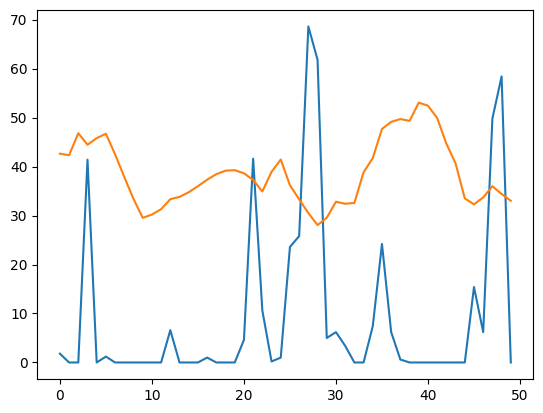

In [73]:
plt.plot(xls['precipitation'].values[0:730][-50:])
plt.plot(pi[-50:]*100)

(array([ 61., 173., 321., 609., 747., 766., 522., 304., 124.,  23.]),
 array([0.15166782, 0.21264096, 0.2736141 , 0.33458724, 0.39556038,
        0.45653352, 0.51750666, 0.5784798 , 0.63945294, 0.70042608,
        0.76139922]),
 <BarContainer object of 10 artists>)

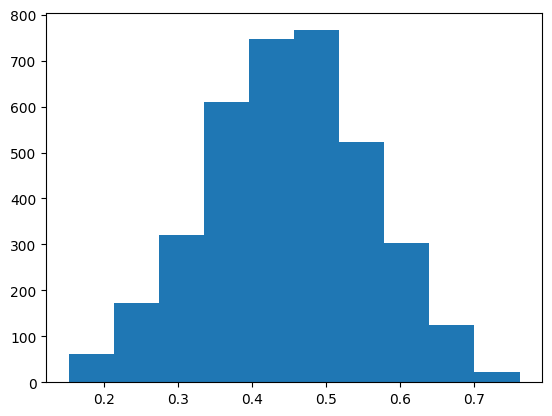

In [42]:
plt.hist(pi)

In [14]:
np.exp(0.998) * (y / np.exp(9.953) - 1)

array([-2.64987361, -2.64755952, -2.64559954, -2.64407762, -2.64305352,
       -2.64077992, -2.63877011, -2.64003817, -2.64087125, -2.64215872,
       -2.64380531, -2.64570423, -2.64774587, -2.64982564, -2.65185024,
       -2.65206514, -2.65359798, -2.6562992 , -2.65787394, -2.6569666 ,
       -2.65797356, -2.65605799, -2.65459178, -2.65314059, -2.65259381,
       -2.65355191, -2.65362757, -2.65315318, -2.65261976, -2.6506407 ,
       -2.64989994, -2.65008778, -2.65213795, -2.65264667, -2.65169024,
       -2.65046425, -2.6535306 , -2.65349543, -2.6544562 , -2.65391578,
       -2.65789224, -2.66067107, -2.66441595, -2.66544061, -2.66614648,
       -2.66826983, -2.66854853, -2.66850116, -2.66815153, -2.66634264,
       -2.66775121, -2.66691902, -2.6683221 , -2.66758443, -2.66675641,
       -2.66469814, -2.662183  , -2.66372548, -2.66175444, -2.66098074,
       -2.66034752, -2.65811893, -2.65755189, -2.65716486, -2.65694442,
       -2.65626999, -2.6593885 , -2.65983168, -2.66026355, -2.66

(array([17897., 18262., 18628., 18993., 19358., 19723., 20089.]),
 [Text(17897.0, 0, '2019'),
  Text(18262.0, 0, '2020'),
  Text(18628.0, 0, '2021'),
  Text(18993.0, 0, '2022'),
  Text(19358.0, 0, '2023'),
  Text(19723.0, 0, '2024'),
  Text(20089.0, 0, '2025')])

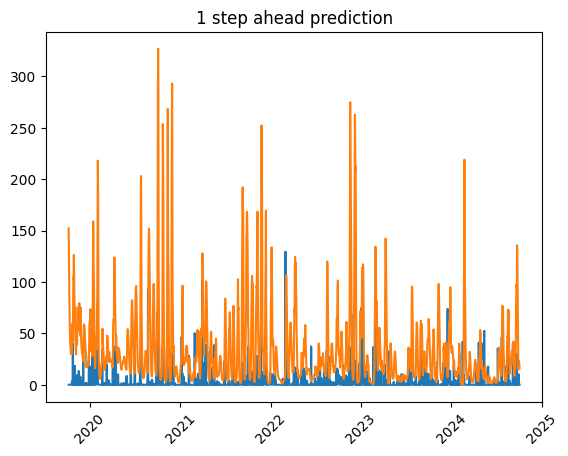

In [82]:
plt.plot(xls['precipitation'][-1825:])
plt.plot(y_fit['precipitation - prediction'])
plt.title("1 step ahead prediction")
plt.xticks(rotation=45)

Saving results

In [3]:
dates = pd.date_range(start='2008-01-01', periods=len(xls), freq='D')
xls.index = dates

In [80]:
xls

,precipitation
2008-01-01,0.0
2008-01-02,0.0
2008-01-03,0.0
2008-01-04,0.0
2008-01-05,14.2
...,...
2024-09-30,10.2
2024-10-01,9.6
2024-10-02,0.0
2024-10-03,0.0


In [81]:
y_fit = pd.DataFrame(y, index = dates[-1825:], columns = ['precipitation - prediction'])

In [40]:
xls

,precipitation
2008-01-01,0.0
2008-01-02,0.0
2008-01-03,0.0
2008-01-04,0.0
2008-01-05,14.2
...,...
2024-09-30,10.2
2024-10-01,9.6
2024-10-02,0.0
2024-10-03,0.0


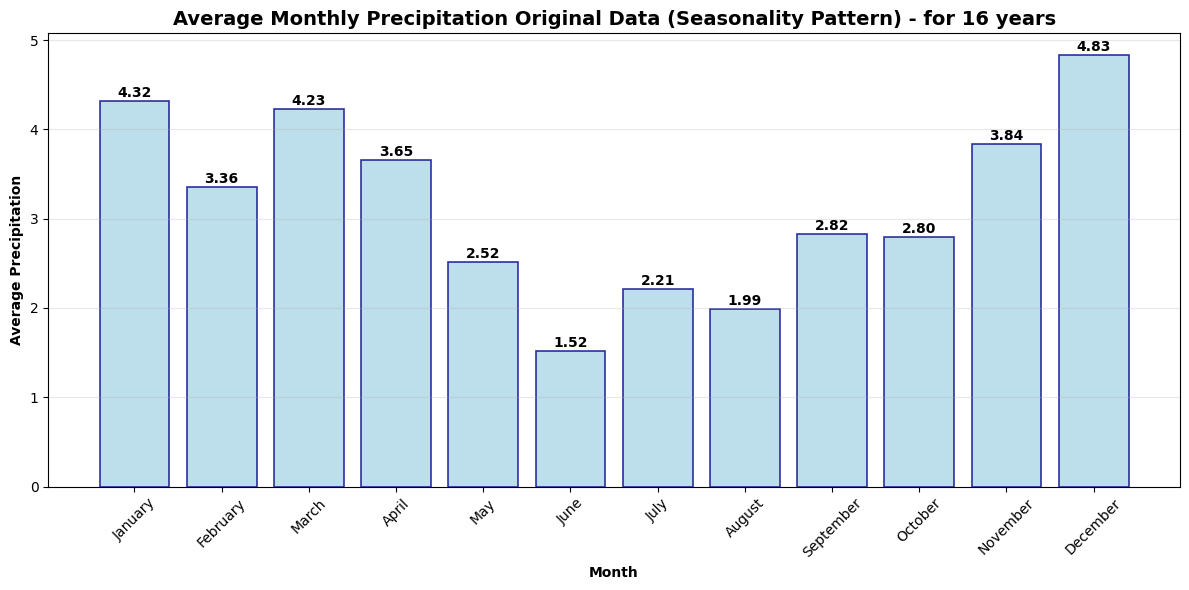

In [41]:
# Calculate monthly averages
monthly_avg = xls.groupby(xls.index.month)['precipitation'].mean()

# Plot with month names
import calendar
month_names = [calendar.month_name[i] for i in monthly_avg.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(month_names, monthly_avg.values, color='lightblue', edgecolor='darkblue', linewidth=1.2, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Monthly Precipitation Original Data (Seasonality Pattern) - for 16 years', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Average Precipitation', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [26]:
y_fit

,precipitation - prediction
2008-01-01,8.665776
2008-01-02,8.629050
2008-01-03,8.575292
2008-01-04,8.508283
2008-01-05,8.432872
...,...
2017-12-24,4.535397
2017-12-25,4.603260
2017-12-26,4.573767
2017-12-27,4.669546


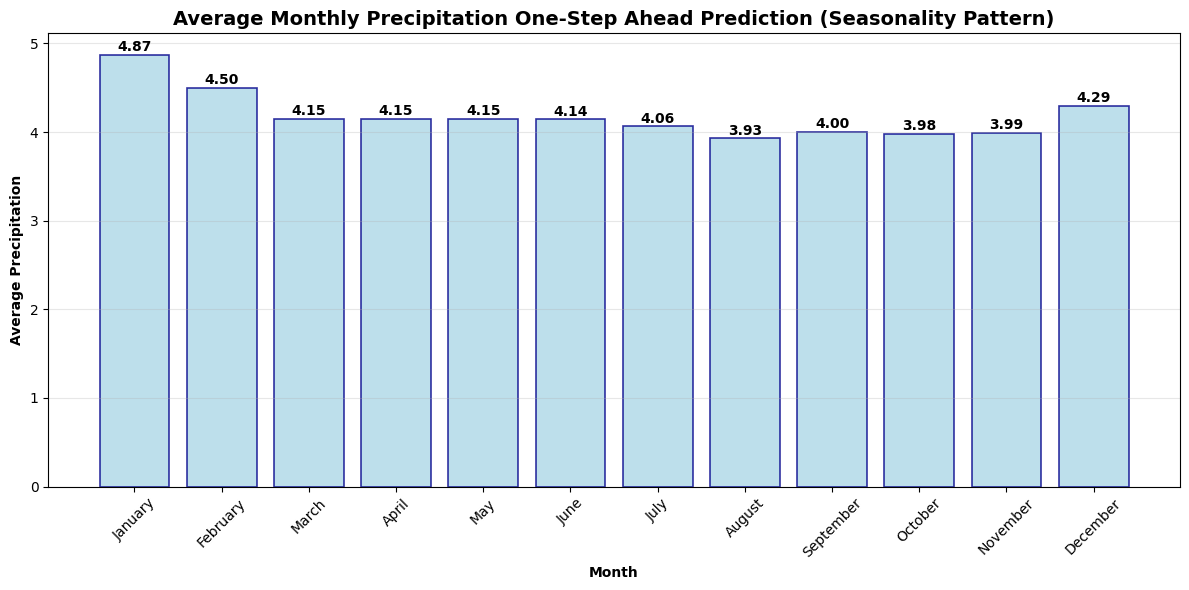

In [25]:
# Calculate monthly averages
monthly_avg = y_fit.groupby(y_fit.index.month)['precipitation - prediction'].mean()

# Plot with month names
import calendar
month_names = [calendar.month_name[i] for i in monthly_avg.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(month_names, monthly_avg.values, color='lightblue', edgecolor='darkblue', linewidth=1.2, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Monthly Precipitation One-Step Ahead Prediction (Seasonality Pattern)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Average Precipitation', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [30]:
fis

array([ 5.00742809e+01,  1.06966158e+01,  1.56334692e-01,  5.20335576e-02,
        1.52916241e-01,  1.99151347e-01, -2.55339192e-01,  4.22153756e-02,
        1.95349364e-01, -3.46860659e-01,  4.46190456e-02, -2.11094123e-01,
       -2.04503233e-01,  1.09029852e-01, -2.39953445e-01,  1.86435517e-01,
        2.85864881e-01, -3.87321827e-01,  3.35623752e-01, -6.70846844e-02,
        2.30687247e-01,  8.49760701e-01, -1.72670072e-01,  4.46723097e-02,
        1.54224886e-01, -1.69047889e-02,  1.27578348e-01,  1.05694741e-01,
       -3.63650228e-02, -2.60406286e-01, -9.94553227e-02, -7.69704799e-02,
       -1.49180302e-02, -2.38721333e-01,  3.12963317e-01,  6.97791150e-02,
        1.26791843e-01,  5.31432352e-01, -6.95236932e-02,  1.28746242e-01,
        2.69923710e-03,  1.18566037e-01,  9.99567502e+00,  9.11098700e+01,
        9.68704271e+01,  4.39778502e+01,  8.01823131e+01,  4.64073606e+01])

In [13]:
pit = dynamics.pit(fis, xls['precipitation'][-730:].values)

In [45]:
pit

array([0.42799062, 0.44151117, 0.45696327, ..., 0.61793372, 0.56373606,
       0.48363651], shape=(3650,))

In [ ]:
p

In [14]:
np.min(pit)

np.float64(0.35401177737089495)

In [18]:
np.max(pit)

np.float64(0.994483525611721)

In [16]:
np.sum(pit < 0.5)

np.int64(390)

Text(0.5, 1.0, 'PIT')

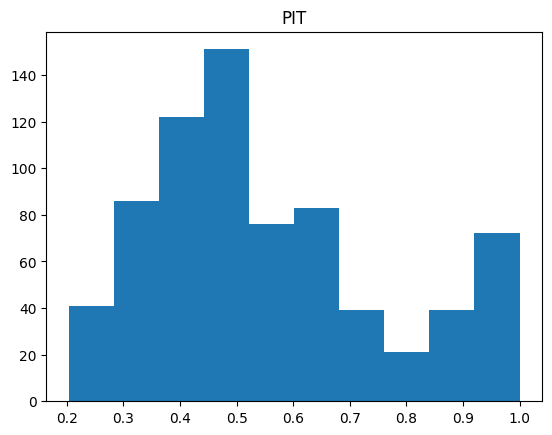

In [14]:
plt.hist(pit)
plt.title("PIT")

In [15]:
quant = dynamics.get_quantile_residuals(pit)

In [16]:
def get_quantile_residuals(pit):
        """
        Calculate quantile residuals from the fitted model.

        Quantile residuals are defined as the inverse standard normal CDF
        applied to the PIT values: r_t = Φ^{-1}(PIT_t)

        Parameters
        ----------
        params : array_like
            Model parameters
        y : array_like
            Observed time series data

        Returns
        -------
        quantile_residuals : ndarray
            Quantile residuals following standard normal distribution
            if the model is correctly specified
        """

        # Transform to quantile residuals using inverse standard normal CDF
        quantile_residuals = stats.uniform.ppf(pit)

        return quantile_residuals

In [17]:
quant = dynamics.get_quantile_residuals(pit)

(array([116., 297., 162.,  44.,  41.,  34.,  21.,   9.,   4.,   2.]),
 array([-0.83022735, -0.37478154,  0.08066426,  0.53611006,  0.99155587,
         1.44700167,  1.90244747,  2.35789328,  2.81333908,  3.26878488,
         3.72423069]),
 <BarContainer object of 10 artists>)

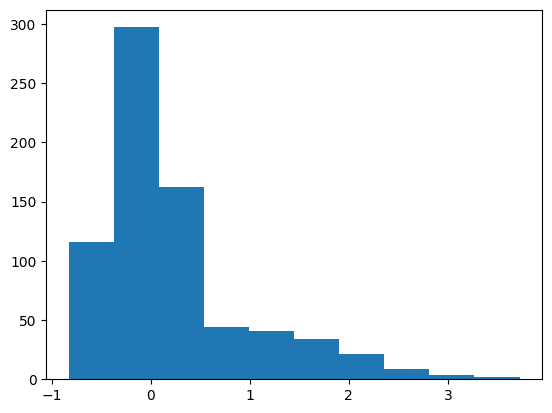

In [18]:
plt.hist(quant)

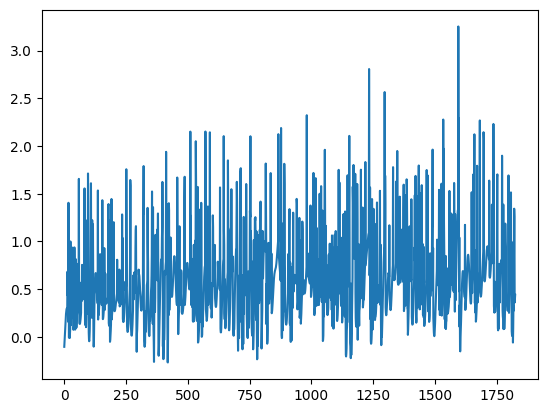

In [88]:
plt.plot(quant)

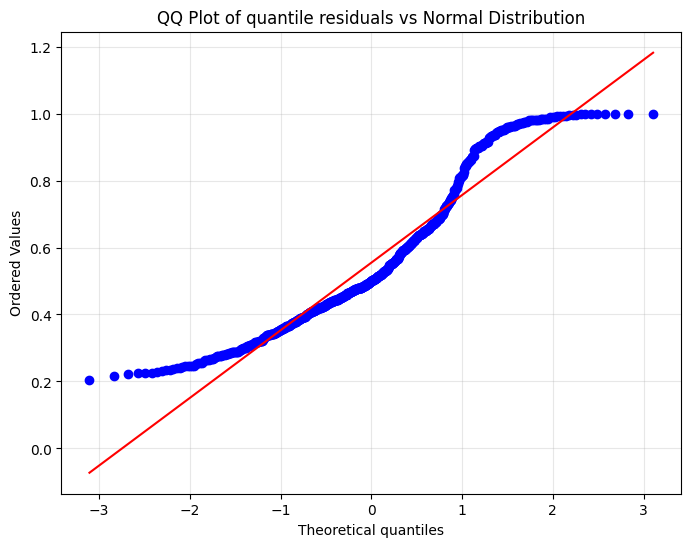

In [19]:
# Create QQ plot
plt.figure(figsize=(8, 6))
stats.probplot(pit, dist="norm", plot=plt)
plt.title('QQ Plot of quantile residuals vs Normal Distribution')
plt.grid(True, alpha=0.3)
plt.show()

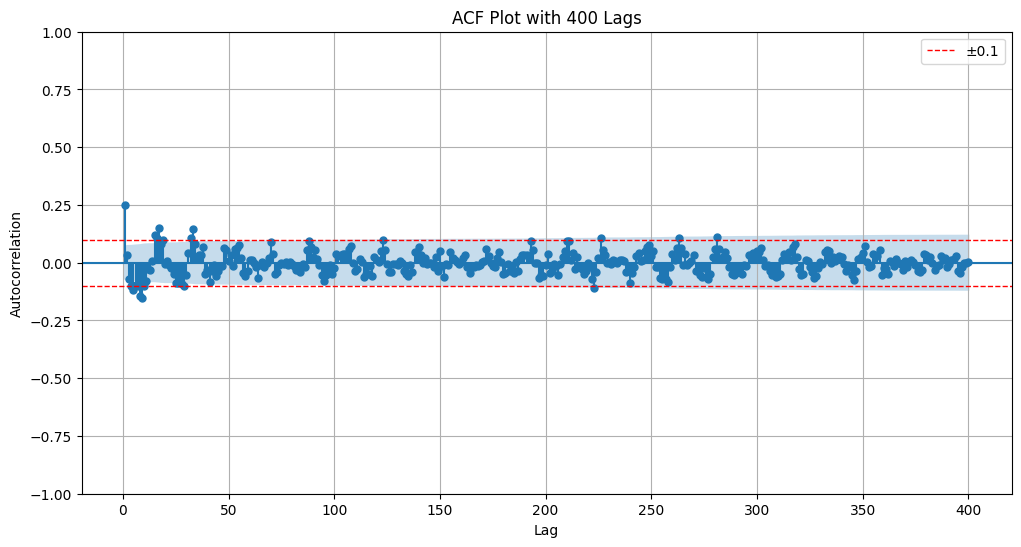

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'quant' is your time series data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ACF without lag 0 by starting from lag 1
plot_acf(quant, lags=400, ax=ax, alpha=0.05, zero=False)

# Add red horizontal lines at -0.1 and 0.1
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)

plt.title('ACF Plot with 400 Lags')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
from scipy.special import digamma, polygamma, beta

In [22]:
def variance(delta_0, delta_1, phi, gamma, xi, zeta):

    # Numerical stability for pi
    linear_comb = delta_0 + delta_1 * phi
    pi = np.exp(linear_comb) / (1 + np.exp(linear_comb))

    # GB2 component moments
    ex = (
        np.exp(phi)
        * beta(np.exp(xi) + np.exp(gamma), np.exp(zeta) - np.exp(gamma))
        / beta(np.exp(xi), np.exp(zeta))
    )

    ex2 = (
        np.exp(phi) ** 2
        * beta(np.exp(xi) + 2 * np.exp(gamma), np.exp(zeta) - 2 * np.exp(gamma))
        / beta(np.exp(xi), np.exp(zeta))
    )

    # Variance of GB2 component
    var_fy = ex2 - ex**2

    # CORRECTED: Zero-inflated mixture variance formula
    # Var(y) = π * σ₁² + π(1-π) * μ₁²
    variance = pi * var_fy + pi * (1 - pi) * ex**2

    return variance

In [103]:
delta_0

NameError: name 'delta_0' is not defined

In [36]:
erro = []
for i in range(730):
    erro.append((df['orig'].values[i] - df['1-step-ahead'].values[i])/variance(delta_0, delta_1, phis[i], gamma_, xi, zeta))

In [37]:
erro

[np.float64(-6.349548403947708e-05),
 np.float64(-0.00012374000527188187),
 np.float64(-0.00012034697546748313),
 np.float64(9.983366259387002e-05),
 np.float64(-0.0003838228168860707),
 np.float64(-7.883293156589672e-05),
 np.float64(-1.0248136660540878e-05),
 np.float64(1.012947598751217e-06),
 np.float64(-2.7520456147102696e-05),
 np.float64(-3.42867221061998e-05),
 np.float64(-4.6767027298805775e-05),
 np.float64(-6.839743519904247e-05),
 np.float64(-0.00010446146709942254),
 np.float64(-0.0001617342974880499),
 np.float64(-0.0002463031554306134),
 np.float64(0.0003490927958134686),
 np.float64(-0.00015693629529937826),
 np.float64(-9.092442997161948e-05),
 np.float64(5.46221199294889e-05),
 np.float64(-1.502135880661323e-05),
 np.float64(-1.421896010454099e-05),
 np.float64(-2.8233043587394005e-06),
 np.float64(-1.6378863202135713e-06),
 np.float64(-1.0658242760120084e-06),
 np.float64(-1.0819738792816846e-06),
 np.float64(-5.166580678962241e-06),
 np.float64(-9.509225827372032e-0

In [ ]:
(df['orig'] - df['1-step-ahead']

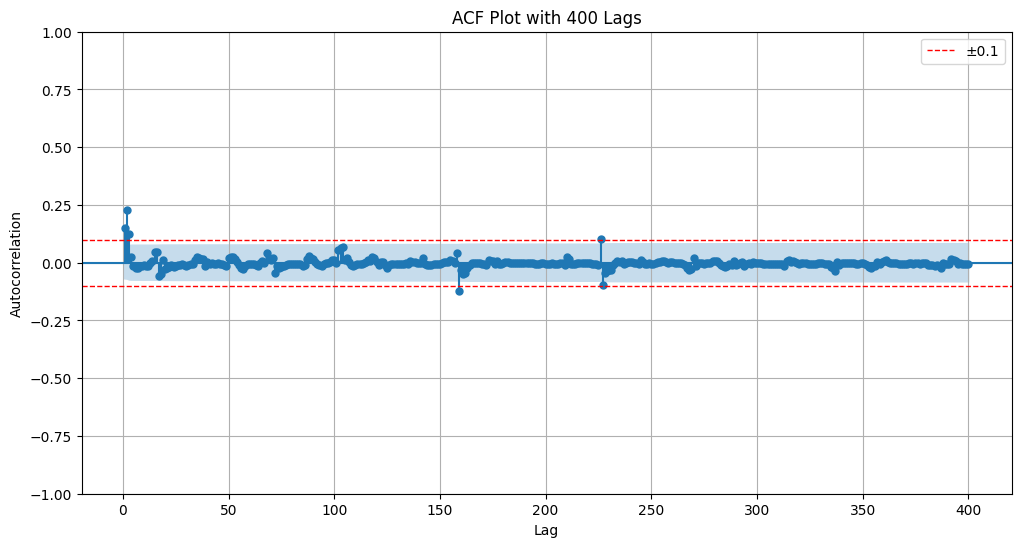

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'quant' is your time series data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ACF without lag 0 by starting from lag 1
plot_acf(erro, lags=400, ax=ax, alpha=0.05, zero=False)

# Add red horizontal lines at -0.1 and 0.1
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)

plt.title('ACF Plot with 400 Lags')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()

In [91]:
from statsmodels.tsa.stattools import acf

# Calculate ACF values for 400 lags
acf_values = acf(quant, nlags=400, fft=True)

print(f"ACF values shape: {acf_values.shape}")
print(f"First 10 ACF values: {acf_values[:10]}")

ACF values shape: (401,)
First 10 ACF values: [ 1.          0.44893416  0.21865644  0.08302788  0.02220808 -0.01778041
 -0.06171926 -0.09630676 -0.09932982 -0.12114146]


In [31]:
gamma = np.zeros(20)
gamma_star = np.zeros(20)

km = fis[0] / 1000
kg = fis[1] / 1000

for i in range(20):
    gamma[i] = fis[i + 2] / 100
    gamma_star[i] = fis[i + 2 + 20] / 100

mu0 = fis[20 * 2 + 2] / 100
delta_0 = fis[20 * 2 + 3] / 100
delta_1 = fis[20 * 2 + 4] / 100
gamma_ = fis[20 * 2 + 5] / 100
xi = fis[20 * 2 + 6] / 100
zeta = fis[20 * 2 + 7] / 100

In [108]:
print(f"km: {km}, kg: {kg}, gamma: {gamma}, gamma_star: {gamma_star}, mu0: {mu0}, delta_0: {delta_0}, delta_1: {delta_1}, gamma_: {gamma_}, xi: {xi}, zeta: {zeta}")

km: 0.027732667174791815, kg: 0.025083341136487785, gamma: [-3.79455482e-04  1.86388146e-03 -4.43999848e-03 -7.14911793e-05
 -3.85385833e-03 -5.58083541e-03  4.41618619e-03  9.10345797e-04
 -3.42414405e-03  4.83570340e-03 -3.47302142e-03 -1.39419925e-03
 -4.50474192e-03  1.57558295e-03  3.72771830e-03  4.06006953e-03
 -4.81564088e-03 -2.20429833e-04 -3.20589541e-04 -6.71878903e-03], gamma_star: [ 1.29579107e-03 -6.22904740e-04 -9.89701123e-05 -2.59738808e-05
  5.59837944e-03 -6.48319855e-03 -1.13260895e-03  4.78877680e-03
 -2.29980867e-03 -3.42529068e-04 -4.52909116e-03 -9.09215202e-03
  6.14044215e-03  2.80031999e-03 -6.57430984e-03 -3.13638400e-03
 -1.04575259e-02 -6.88783059e-03 -4.35493164e-03 -6.77868100e-03], mu0: 0.09629200261292464, delta_0: 0.12915512435930307, delta_1: 0.5048662006269842, gamma_: 1.2869986482123794, xi: 2.385101502801308, zeta: 1.6330047293948575


In [61]:
(xls['precipitation'] == 0).sum()

np.int64(3769)

In [33]:
def fit_in_sample(params, y, size):
    gamma = np.zeros(20)
    gamma_star = np.zeros(20)

    km = params[0] / 1000
    kg = params[1] / 1000

    for i in range(20):
        gamma[i] = params[i + 2] / 100
        gamma_star[i] = params[i + 2 + 20] / 100

    mu0 = params[20 * 2 + 2] / 100
    delta_0 = params[20 * 2 + 3] / 100
    delta_1 = params[20 * 2 + 4] / 100
    gamma_ = params[20 * 2 + 5] / 100
    xi = params[20 * 2 + 6] / 100
    zeta = params[20 * 2 + 7] / 100

    mu = mu0
    fit_in_sample = np.zeros(size)
    mean_gb2 = np.zeros(size)
    pi = np.zeros(size)
    gammas = np.zeros(size)
    phis = np.zeros(size)

    for t in range(size):
        phi = mu + np.sum(gamma)
        phis[t] = phi
        gammas[t] = np.exp(np.sum(gamma))

        score = ZAGB2LogLinkDistribution().score(
            y[t],
            delta_0=delta_0,
            delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )[0]
        mean_gb2[t], fit_in_sample[t] = ZAGB2LogLinkDistribution().mean(
            delta_0=delta_0,
            delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )
        mu += km * score
        pi[t] = np.exp(delta_0 + delta_1 * phi) / (
            1 + np.exp(delta_0 + delta_1 * phi)
        )

        for i in range(20):
            lambda_i = (2 * np.pi * (i + 1)) / 365.25
            gamma_t1 = (
                np.cos(lambda_i) * gamma[i]
                + np.sin(lambda_i) * gamma_star[i]
                + kg * score
            )
            gamma_start_t1 = (
                np.cos(lambda_i) * gamma_star[i]
                - np.sin(lambda_i) * gamma[i]
                + kg * score
            )
            gamma[i] = gamma_t1
            gamma_star[i] = gamma_start_t1

    return mean_gb2, fit_in_sample, pi, gammas, phis

In [34]:
m, f, pi, gammas, phis = fit_in_sample(fis, xls['precipitation'], 1825)

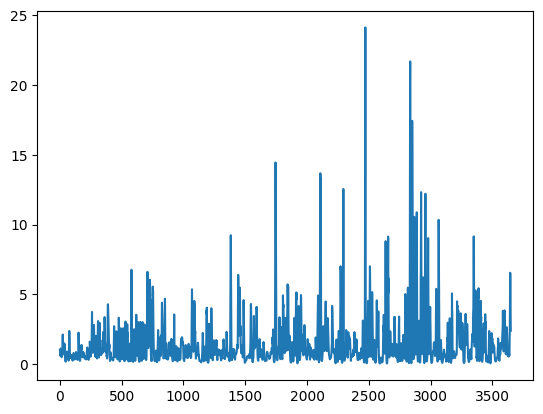

In [21]:
plt.plot(gammas)

In [26]:
y_fit = pd.DataFrame(gammas, index = dates, columns = ['gamma'])

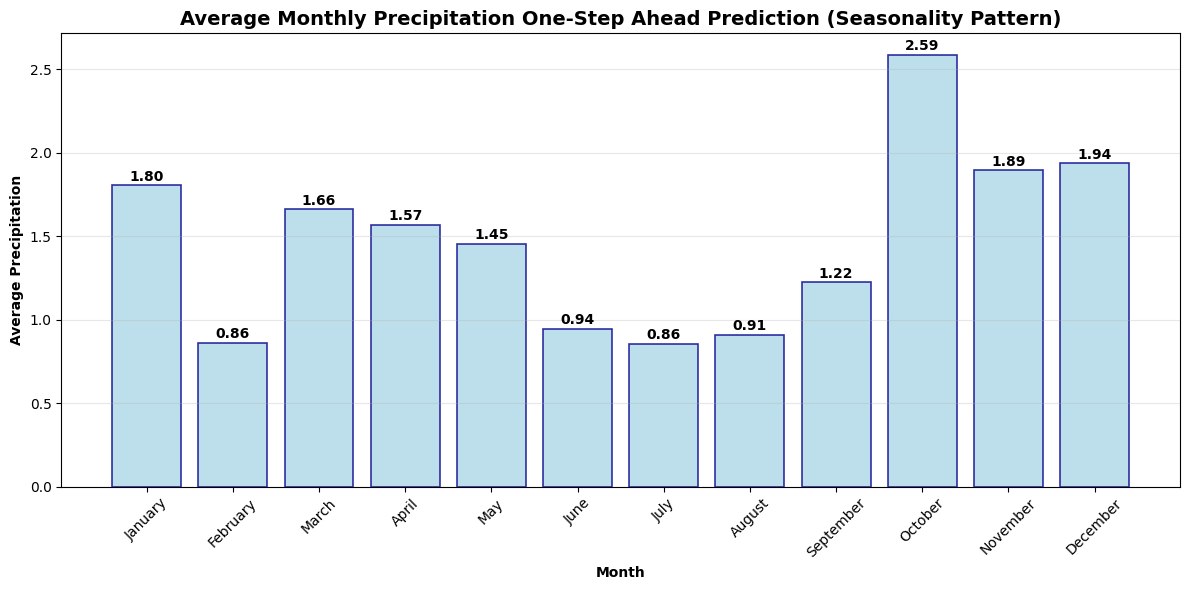

In [27]:
# Calculate monthly averages
monthly_avg = y_fit.groupby(y_fit.index.month)['gamma'].mean()

# Plot with month names
import calendar
month_names = [calendar.month_name[i] for i in monthly_avg.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(month_names, monthly_avg.values, color='lightblue', edgecolor='darkblue', linewidth=1.2, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Monthly Precipitation One-Step Ahead Prediction (Seasonality Pattern)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Average Precipitation', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Simulation

In [2]:
y = Simulator().simulate(1825, 20, 365.25, seed=42)

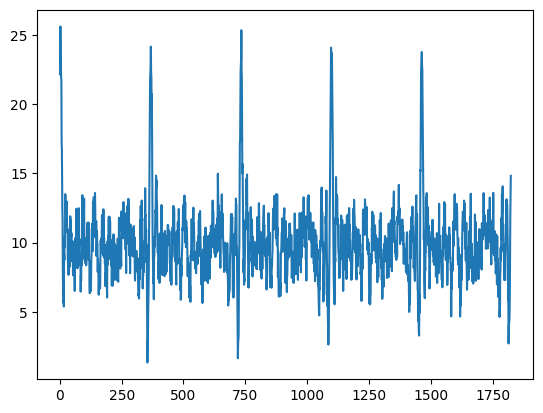

In [3]:
plt.plot(y)

In [4]:
# Create dynamics object
dynamics = Dynamics(
    distribution=GB2LogLinkDistribution(),
    n=len(y),
    trend=None,
    seasonality=None,
    harmonics=20,
    period=365.25,
    time_varying_indices=[0],
    fixed_params_indices=[1],
    args=[0.05, 0.02]
)


In [5]:
initial_params = dynamics.get_initial_values(y)

Initial parameter check:
km: 20 (bounds: 1-2000) - OK
kg: 20 (bounds: 1-2000) - OK
gamma_0: 0.0 (bounds: -200-200) - OK
mu0: 10 (bounds: -1000-1000) - OK
gamma_: 20 (bounds: 10-500) - OK
xi: 200 (bounds: 10-500) - OK
zeta: 200 (bounds: 20-1000) - OK
zeta > gamma_: True - OK


In [ ]:
bounds = [
    # km, kg - learning rates (will be divided by 1000)
    (-2000, 2000),      # km: results in 0.001 to 2.0 after scaling
    (-2000, 2000),      # kg: results in 0.001 to 2.0 after scaling
] + [
    # 40 seasonal parameters (20 gamma + 20 gamma_star)
    (-200, 200) for _ in range(40)
] + [
    # 6 distribution parameters
    (-1000, 1000),  # mu0: results in -10.0 to 10.0 after scaling
    # (-2000, 2000),    # delta_0: results in -2.0 to 2.0 after scaling  
    # (-1000, 1000),    # delta_1: results in -1.0 to 1.0 after scaling
    (1, 10000),      # gamma_: results in 0.1 to 5.0 after scaling (must be > 0)
    (0, 10000),      # xi: results in 0.1 to 5.0 after scaling (must be > 0)
    (1.2, 10000)      # zeta: results in 0.2 to 10.0 after scaling (must be > gamma_)
]

result = minimize(
    dynamics.objective,
    x0=initial_params,
    args=(y, bounds),
    method='BFGS',
    options={
        'gtol': 1e-1,
        'maxiter': 100,
        'disp': True
    }
)

c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


         Current function value: 10.813416
         Iterations: 5
         Function evaluations: 758
         Gradient evaluations: 16


c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [25]:
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 10.813415940926955
        x: [ 2.806e+01  1.528e+01 ...  8.127e+00  1.748e+02]
      nit: 5
      jac: [-1.262e-03 -2.193e-03 ...  8.426e-03  5.903e-02]
 hess_inv: [[ 8.708e+00 -4.491e+00 ... -1.833e+02 -2.445e+01]
            [-4.491e+00  3.617e+00 ...  1.068e+02  1.424e+01]
            ...
            [-1.833e+02  1.068e+02 ...  4.362e+03  5.815e+02]
            [-2.445e+01  1.424e+01 ...  5.815e+02  7.854e+01]]
     nfev: 758
     njev: 16

In [38]:
result['x']

array([ 2.80603526e+01,  1.52841444e+01,  8.92381242e-01,  8.77681901e-01,
        8.77689821e-01,  8.79225869e-01,  8.68799548e-01,  8.64872749e-01,
        8.58653626e-01,  8.67428626e-01,  8.61209379e-01,  8.63631709e-01,
        8.69290093e-01,  8.55714022e-01,  8.61495798e-01,  8.50259204e-01,
        8.62023743e-01,  8.52433054e-01,  8.51391515e-01,  8.38418762e-01,
        8.42502815e-01,  8.43864345e-01,  4.64043503e-03,  7.75537347e-03,
        5.21986178e-03, -1.77578335e-03, -4.10001006e-03,  5.24751345e-03,
       -4.10129022e-03, -1.71803646e-03,  5.76137287e-03, -8.99624632e-03,
        4.50844293e-03, -5.62844154e-03, -2.02784961e-03, -1.73411421e-02,
       -1.19241421e-03, -1.12684433e-03,  8.77068145e-03, -4.82591583e-03,
       -2.19859723e-03, -1.38561583e-02,  1.15072178e+01,  1.42426244e+01,
        8.12688661e+00,  1.74797257e+02])

In [8]:
y_fit = dynamics.fit_in_sample(result['x'], y)

TypeError: cannot unpack non-iterable numpy.float64 object

In [26]:
def fit_in_sample(params, y):
    gamma = np.zeros(20)
    gamma_star = np.zeros(20)

    km = params[0] / 1000
    kg = params[1] / 1000

    for i in range(20):
        gamma[i] = params[i + 2] / 100
        gamma_star[i] = params[i + 2 + 20] / 100

    mu0 = params[20 * 2 + 2] / 100
    # delta_0 = params[20 * 2 + 3] / 100
    # delta_1 = params[20 * 2 + 4] / 100
    # gamma_ = params[20 * 2 + 5] / 100
    # xi = params[20 * 2 + 6] / 100
    # zeta = params[20 * 2 + 7] / 100

    gamma_ = params[20 * 2 + 3] / 100
    xi = params[20 * 2 + 4] / 100
    zeta = params[20 * 2 + 5] / 100

    mu = mu0
    fit_in_sample = np.zeros(len(y))
    phis = np.zeros(len(y))
    
    for t in range(len(y)):
        phi = mu + np.sum(gamma)
        phis[t] = phi

        score = GB2LogLinkDistribution().score(
            y[t],
            # delta_0=delta_0,
            # delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )[0]
        fit_in_sample[t] = GB2LogLinkDistribution().mean(
            # delta_0=delta_0,
            # delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )
        mu += km * score
        # pi[t] = np.exp(delta_0 + delta_1 * phi) / (
        #     1 + np.exp(delta_0 + delta_1 * phi)
        # )

        for i in range(20):
            lambda_i = (2 * np.pi * (i + 1)) / 365.25
            gamma_t1 = (
                np.cos(lambda_i) * gamma[i]
                + np.sin(lambda_i) * gamma_star[i]
                + kg * score
            )
            gamma_start_t1 = (
                np.cos(lambda_i) * gamma_star[i]
                - np.sin(lambda_i) * gamma[i]
                + kg * score
            )
            gamma[i] = gamma_t1
            gamma_star[i] = gamma_start_t1

    return fit_in_sample, phis, gamma_, xi, zeta

In [27]:
y_fit, phis, gamma_, xi, zeta = fit_in_sample(result['x'], y)

In [28]:
zeta

np.float64(1.7479725700526538)

In [29]:
 GB2LogLinkDistribution().mean(
            # delta_0=delta_0,
            # delta_1=delta_1,
            phi=phis[10],
            gamma=gamma_,
            xi=xi,
            zeta=2.0,
        )

np.float64(4.714991621758234)

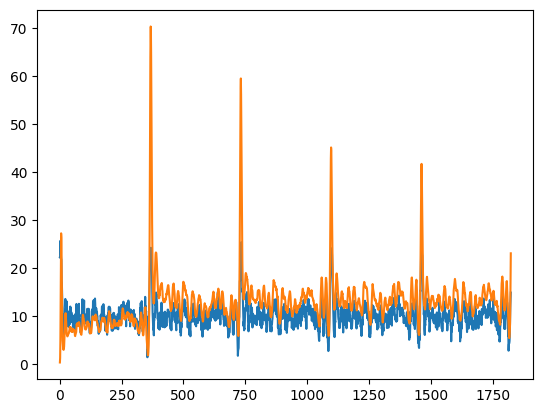

In [30]:
plt.plot(y)
plt.plot(y_fit)

In [31]:
def cdf(y, phi, gamma, xi, zeta):
    # Correct parameter mapping based on your specification:
    a = np.exp(-gamma)  # a = exp(-f2) where f2 is gamma
    b = np.exp(phi)     # b = exp(phi)
    p = xi              # p = xi (directly)
    q = zeta            # q = zeta (directly)
    
    # GB2 CDF: F(y) = I_{z/(1+z)}(a, b) where z = (y/b)^p
    # Note: In standard GB2 notation, the scale parameter is typically 'b'
    z = (y / b) ** p
    
    # Regularize to avoid numerical issues
    z = np.maximum(z, 1e-16)  # Ensure positive
    u = z / (1 + z)
    u = np.clip(u, 1e-16, 1 - 1e-16)  # Keep within (0,1) for betainc
    
    gb2_cdf = betainc(a, q, u)  # Note: using 'q' as the second parameter
    
    return gb2_cdf

In [32]:
pit = dynamics.pit(result['x'], y)

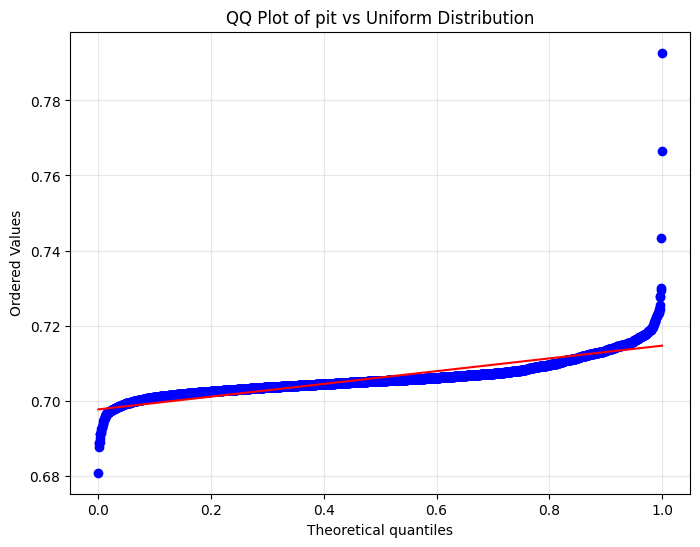

In [33]:
# Create QQ plot
plt.figure(figsize=(8, 6))
stats.probplot(pit, dist="uniform", plot=plt)
plt.title('QQ Plot of pit vs Uniform Distribution')
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
quant = dynamics.get_quantile_residuals(pit)

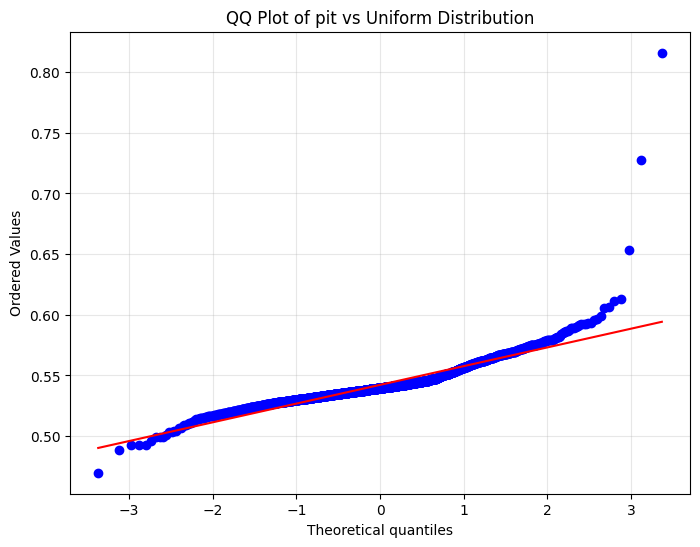

In [35]:
# Create QQ plot
plt.figure(figsize=(8, 6))
stats.probplot(quant, dist="norm", plot=plt)
plt.title('QQ Plot of pit vs Uniform Distribution')
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
phis

array([0.28746186, 1.78719804, 3.17641425, ..., 4.09029711, 4.44379754,
       4.74994945], shape=(1825,))

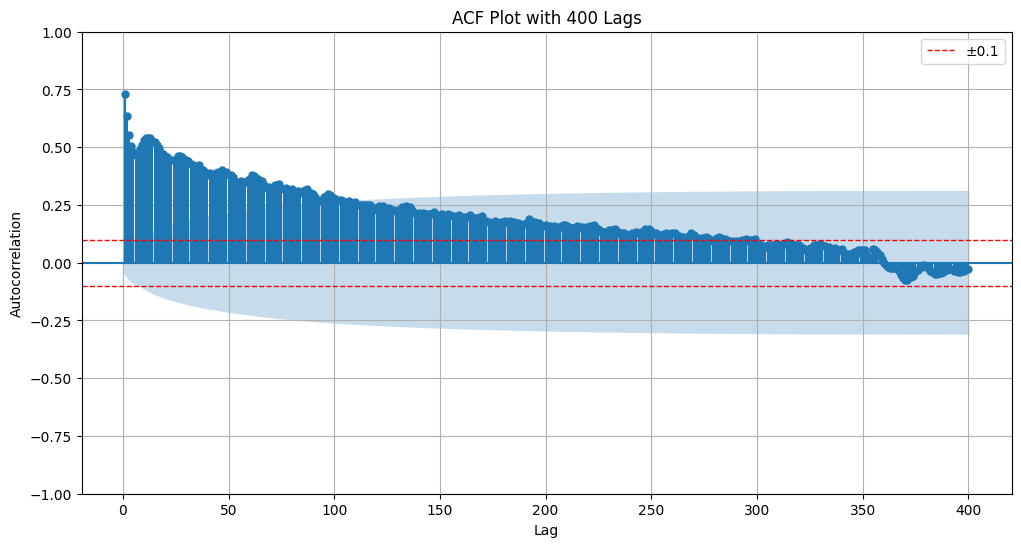

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'quant' is your time series data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ACF without lag 0 by starting from lag 1
plot_acf(pit, lags=400, ax=ax, alpha=0.05, zero=False)

# Add red horizontal lines at -0.1 and 0.1
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)

plt.title('ACF Plot with 400 Lags')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
erro = []
for t,_ in enumerate(y):
    erro.append((y[t] - y_fit[t])/GB2LogLinkDistribution().variance(
        phi = phis[t],
        gamma = gamma_,
        xi = xi,
        zeta = zeta
    ))

In [22]:
erro

[np.float64(36.98156547299431),
 np.float64(0.5100178019962361),
 np.float64(-0.0014793498201008319),
 np.float64(-0.014057322594553168),
 np.float64(-0.014503079751526099),
 np.float64(-0.01329048397485575),
 np.float64(-0.004389245503719134),
 np.float64(-0.005830905685634112),
 np.float64(0.02133941011625852),
 np.float64(0.018937542037524506),
 np.float64(0.025293381450546163),
 np.float64(0.03294562001101274),
 np.float64(-0.025432429248991667),
 np.float64(-0.014807086969960801),
 np.float64(-0.01701840678727603),
 np.float64(0.012232583964554752),
 np.float64(-0.018749125643744438),
 np.float64(0.1247534052977436),
 np.float64(-0.0089977295600397),
 np.float64(-0.0040756025257572956),
 np.float64(-0.024542377860114442),
 np.float64(1.3285875062953041e-05),
 np.float64(0.0013901054634202117),
 np.float64(-0.01445342436727933),
 np.float64(-0.0043888592717459445),
 np.float64(-0.003969670168252648),
 np.float64(0.00895018387680522),
 np.float64(0.007089157941125278),
 np.float64(0

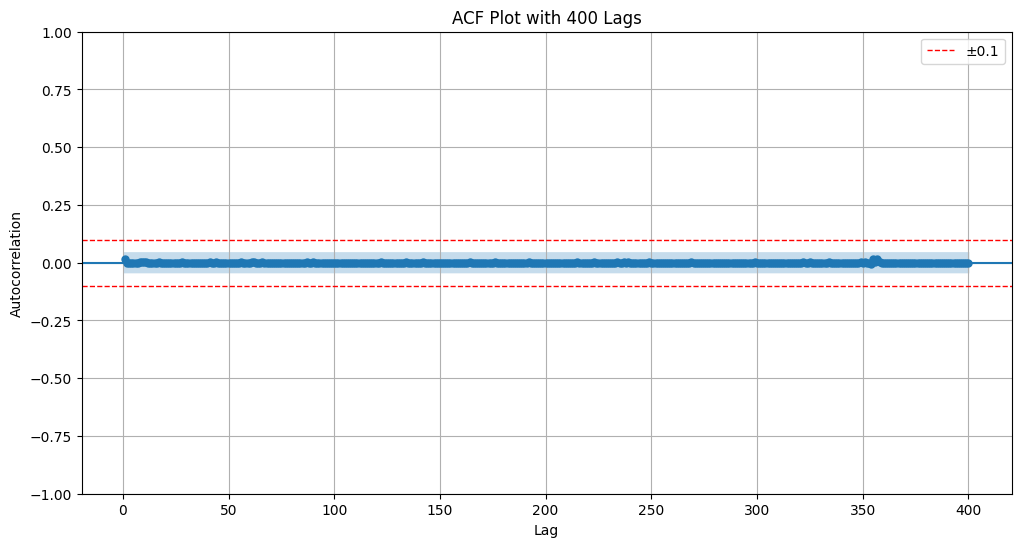

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'quant' is your time series data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ACF without lag 0 by starting from lag 1
plot_acf(erro, lags=400, ax=ax, alpha=0.05, zero=False)

# Add red horizontal lines at -0.1 and 0.1
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)

plt.title('ACF Plot with 400 Lags')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()